### Initial Database and Checks


In [ ]:
import os
import tensorflow as tf

# NOTE: may have to change batch size and epochs depending on GPU VRAM. but epochs should be kept to 100 if possible for train accuracy.
# dataset vars
TRAIN_END = 15000
TEST_SIZE = int(TRAIN_END * 0.20)
HOLDOUT_END = TRAIN_END + TEST_SIZE
# secret text vars
MAX_CHARS = 20
DELIM = "|||END|||"
PAD_CHAR = "\x00"
# training vars
CLEAR_BEFORE_TRAIN = True
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 1e-3
STEPS = TRAIN_END//2 // BATCH_SIZE + 1
ALPHA = 1.0
BETA = 20.0
RS_BYTES = 8
# when to start, finish ramp, and std of noise in training loop to improve resilience
START_NOISE_EP = 10
PEAK_NOISE_EP = 40
# Define your checkpoint directory
checkpoint_dir = './checkpoints/'
models_dir = './models/'
data_dir = './data/'
prep_model_path = os.path.join(models_dir, 'prep_model.keras')
hide_model_path = os.path.join(models_dir, 'hide_model.keras')
reveal_model_path = os.path.join(models_dir, 'reveal_model.keras')


I0000 00:00:1775093480.936965   98224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775093480.972188   98224 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775093482.540168   98224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
tf.keras.backend.clear_session()

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

tf.keras.mixed_precision.set_global_policy('mixed_float16')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"
# === GPU CHECK ===
print("=" * 60)
print("GPU/CUDA Configuration Check")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Devices Available: {len(physical_devices)}")
if physical_devices:
    for i, gpu in enumerate(physical_devices):
        print(f"  GPU {i}: {gpu}")
else:
    print("  ⚠️  WARNING: No GPUs detected! Training will be SLOW.")

# Display nvidia-smi output
print("\n" + "=" * 60)
print("NVIDIA GPU Status (nvidia-smi)")
print("=" * 60)
try:
    import subprocess
    result = subprocess.run(
        ['nvidia-smi'], capture_output=True, text=True, timeout=5)
    print(result.stdout)
    if result.stderr:
        print("Errors:", result.stderr)
except Exception as e:
    print(f"Could not run nvidia-smi: {e}")
print("=" * 60 + "\n")


# Load Dataset
dataset = load_dataset("zh-plus/tiny-imagenet")
shuffled_train = dataset['train'].shuffle(seed=42)
shuffled_valid = dataset['valid'].shuffle(seed=42)

train_pool_pil = shuffled_train.select(range(TRAIN_END))['image']
test_pool_pil = shuffled_valid.select(range(TEST_SIZE))['image']
holdout_pool_pil = shuffled_train.select(
    range(TRAIN_END, HOLDOUT_END))['image']


def pil_to_np(pil_list):
    return np.array([np.array(img.convert('RGB'), dtype=np.uint8) for img in pil_list])


print("Converting pools to NumPy arrays...")
train_pool_np = pil_to_np(train_pool_pil)
test_pool_np = pil_to_np(test_pool_pil)
holdout_pool_np = pil_to_np(holdout_pool_pil)

print(
    f"Randomly sampled {len(train_pool_np)} train, {len(test_pool_np)} test, and {len(holdout_pool_np)} holdout images.")

train_cover_np, train_secret_np = train_test_split(
    train_pool_np, train_size=0.5, shuffle=True)
test_cover_np, test_secret_np = train_test_split(
    test_pool_np, train_size=0.5, shuffle=True)
holdout_cover_np, holdout_secret_np = train_test_split(
    holdout_pool_np, train_size=0.5, shuffle=True)


def to_scale(img):
    img = tf.cast(img, tf.float32) / 255.0
    return img


train_dataset = tf.data.Dataset.from_tensor_slices((train_cover_np, train_secret_np)) \
    .shuffle(10000) \
    .batch(BATCH_SIZE) \
    .map(lambda c, s: (to_scale(c), to_scale(s)), num_parallel_calls=tf.data.AUTOTUNE) \
    .prefetch(tf.data.AUTOTUNE)

# TEST: Batch + Scale (No Shuffle)
test_dataset = tf.data.Dataset.from_tensor_slices((test_cover_np, test_secret_np)) \
    .batch(BATCH_SIZE) \
    .map(lambda c, s: (to_scale(c), to_scale(s)), num_parallel_calls=tf.data.AUTOTUNE) \
    .prefetch(tf.data.AUTOTUNE)

# HOLDOUT: Batch + Scale (No Shuffle)
holdout_dataset = tf.data.Dataset.from_tensor_slices((holdout_cover_np, holdout_secret_np)) \
    .map(lambda c, s: (to_scale(c), to_scale(s)), num_parallel_calls=tf.data.AUTOTUNE) \
    .prefetch(tf.data.AUTOTUNE)

print(
    f"✓ Image conversion complete! ({len(train_dataset)} training pairs), ({len(test_dataset)} test pairs), ({len(holdout_dataset)} holdout pairs)")
# Clean up memory
del train_pool_pil, test_pool_pil, holdout_pool_pil, \
    train_pool_np, test_pool_np, holdout_pool_np, \
    train_cover_np, train_secret_np, test_cover_np, \
    test_secret_np, holdout_cover_np, holdout_secret_np


GPU/CUDA Configuration Check
TensorFlow version: 2.21.0
GPU Devices Available: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

NVIDIA GPU Status (nvidia-smi)
Thu Apr  2 01:31:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti     On  |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P8             12W /  165W |  

I0000 00:00:1775093487.765335   98224 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5517 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


### NN Arch and Setup


In [ ]:
from tensorflow.keras import layers, Model
import keras
import tensorflow as tf

initializer = tf.keras.initializers.GlorotNormal(seed=12541)


def build_branch(inputs, kernel_size, name_prefix):
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_1')(inputs)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_2')(x)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_3')(x)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_4')(x)
    return x


def build_stable_branch(inputs, kernel_size, name_prefix):
    shortcut = inputs
    x = inputs

    for i in range(4):
        x = layers.Conv2D(
            50, kernel_size, padding='same', kernel_initializer=initializer, bias_initializer='zeros',
            name=f'{name_prefix}_{i+1}_conv'
        )(x)

        x = layers.BatchNormalization(
            name=f'{name_prefix}_{i+1}_bn'
        )(x)

        x = layers.Activation('relu',
                              name=f'{name_prefix}_{i+1}_relu'
                              )(x)

    # Match channels if needed
    if shortcut.shape[-1] != 50:
        shortcut = layers.Conv2D(
            50, (1, 1), padding='same', kernel_initializer=initializer,
            name=f'{name_prefix}_proj'
        )(shortcut)

    x = layers.Add(name=f'{name_prefix}_residual_add')([x, shortcut])

    return x


def build_keras_prep_network(input_shape=(64, 64, 3)):
    inputs = layers.Input(shape=input_shape, name="secret_image")

    # --- 3x3, 4x4, 5x5 Branches ---
    p3 = build_branch(inputs, (3, 3), "prep_conv3x3")
    p4 = build_branch(inputs, (4, 4), "prep_conv4x4")
    p5 = build_branch(inputs, (5, 5), "prep_conv5x5")

    # --- Concatenation (150 channels) ---
    concat_1 = layers.Concatenate(axis=3, name="prep_concat_1")([p3, p4, p5])

    # --- Final Processing (Layer 5) ---
    # These take concat_1 as input to fuse the multi-scale features
    p3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv3x3_5')(concat_1)
    p4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv4x4_5')(concat_1)
    p5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv5x5_5')(concat_1)

    outputs = layers.Concatenate(
        axis=3, name="prep_concat_final")([p3_f, p4_f, p5_f])

    return Model(inputs=inputs, outputs=outputs, name="Keras_PrepNetwork")


In [ ]:
def build_keras_hide_network(input_shape=(64, 64, 3), prep_channels=150):
    # Inputs
    cover_input = layers.Input(shape=input_shape, name="cover_input")
    prep_input = layers.Input(shape=(64, 64, prep_channels), name="prep_input")

    # Concatenate Cover and Prep (3 + 150 = 153 channels)
    concat_1 = layers.Concatenate(axis=3, name="hide_concat_1")([
        cover_input, prep_input])

    # --- 3x3, 4x4, 5x5 Branches ---

    h3 = build_branch(concat_1, (3, 3), "hide_conv3x3")
    h4 = build_branch(concat_1, (4, 4), "hide_conv4x4")
    h5 = build_branch(concat_1, (5, 5), "hide_conv5x5")

    # --- Second Concatenation (150 channels) ---
    concat_2 = layers.Concatenate(axis=3, name="hide_concat_2")([h3, h4, h5])

    # --- Final Branch Processing ---
    h3_f = layers.Conv2D(50, (3, 3), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv3x3_5')(concat_2)
    h4_f = layers.Conv2D(50, (4, 4), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv4x4_5')(concat_2)
    h5_f = layers.Conv2D(50, (5, 5), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv5x5_5')(concat_2)

    concat_final = layers.Concatenate(
        axis=3, name="hide_concat_final")([h3_f, h4_f, h5_f])

    # --- Output (Stego Image) ---
    # Using Sigmoid to ensure pixel values are between 0 and 1
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='stego_output')(concat_final)

    return Model(inputs=[cover_input, prep_input], outputs=output, name="Keras_HideNetwork")


In [ ]:
def build_keras_reveal_network(input_shape=(64, 64, 3)):
    stego_input = layers.Input(shape=input_shape, name="stego_input")

    # --- 3x3, 4x4, 5x5 Branches ---

    r3 = build_branch(stego_input, (3, 3), "reveal_conv3x3")
    r4 = build_branch(stego_input, (4, 4), "reveal_conv4x4")
    r5 = build_branch(stego_input, (5, 5), "reveal_conv5x5")

    # --- Concatenation (150 channels) ---
    concat_1 = layers.Concatenate(axis=3, name="reveal_concat_1")([r3, r4, r5])

    # --- Final Processing ---
    r3_f = layers.Conv2D(50, (3, 3), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv3x3_5')(concat_1)
    r4_f = layers.Conv2D(50, (4, 4), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv4x4_5')(concat_1)
    r5_f = layers.Conv2D(50, (5, 5), padding='same', activation=None,
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv5x5_5')(concat_1)

    concat_final = layers.Concatenate(
        axis=3, name="reveal_concat_final")([r3_f, r4_f, r5_f])

    # --- Output (Revealed Secret) ---
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='revealed_secret')(concat_final)

    return Model(inputs=stego_input, outputs=output, name="Keras_RevealNetwork")


In [ ]:
import tensorflow as tf
import numpy as np
import random
import string

prep_network = build_keras_prep_network()
hide_network = build_keras_hide_network()
reveal_network = build_keras_reveal_network()


def steganography_loss(cover_input, secret_input, cover_output, secret_output, alpha=1.0, beta=10.0):
    c_in = tf.cast(cover_input, tf.float32)
    s_in = tf.cast(secret_input, tf.float32)
    c_out = tf.cast(cover_output, tf.float32)
    s_out = tf.cast(secret_output, tf.float32)

    # Calculate individual MSE
    cover_mse = tf.reduce_mean(tf.square(c_in - c_out))
    # changing to bce to hopefully make fidelity better
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    secret_bce = bce(s_in, s_out)

    # Total loss
    total_loss = (tf.cast(alpha, tf.float32) * cover_mse) + \
        (tf.cast(beta, tf.float32) * secret_bce)

    return total_loss, cover_mse, secret_bce


def compute_max_chars(capacity_bytes, rs_bytes, delim_len):
    max_chars = capacity_bytes - rs_bytes - delim_len - 2
    return max(1, max_chars)


class StegoSystem(tf.keras.Model):
    def __init__(self, prep_net, hide_net, reveal_net, stego_tools,
                 steps_per_epoch, max_safe_chars=12,
                 alpha=1.0, beta=10.0,
                 noise_start_epoch=10, noise_peak_epoch=40):
        super(StegoSystem, self).__init__()

        self.prep_net = prep_net
        self.hide_net = hide_net
        self.reveal_net = reveal_net
        self.stego_tools = stego_tools

        self.max_safe_chars = max(4, max_safe_chars)
        self.beta = beta
        self.alpha = alpha

        self.methods = ['none', 'lsb', 'dct',
                        'dwt', 'spread_spectrum', 'statistical']

        # Curriculum schedule (step-based)
        self.noise_start_step = tf.Variable(
            float(noise_start_epoch * steps_per_epoch),
            trainable=False, dtype=tf.float32
        )
        self.noise_peak_step = tf.Variable(
            float(noise_peak_epoch * steps_per_epoch),
            trainable=False, dtype=tf.float32
        )

        # Metrics
        self.method_psnr = [
            tf.keras.metrics.Mean(name=f"psnr_{m}")
            for m in self.methods
        ]

        self.method_ssim = [
            tf.keras.metrics.Mean(name=f"ssim_{m}")
            for m in self.methods
        ]
        self.psnr_c_tracker = tf.keras.metrics.Mean(name="cover_psnr")
        self.ssim_s_tracker = tf.keras.metrics.Mean(name="secret_ssim")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.c_loss_tracker = tf.keras.metrics.Mean(name="cover_loss")
        self.s_loss_tracker = tf.keras.metrics.Mean(name="secret_loss")
        self.noise_prob_metric = tf.keras.metrics.Mean(name="noise_prob")
        self.payload_len_tracker = tf.keras.metrics.Mean(name="payload_len")

    @property
    def metrics(self):
        base = [
            self.total_loss_tracker,
            self.psnr_c_tracker,
            self.ssim_s_tracker,
            self.c_loss_tracker,
            self.s_loss_tracker,
            self.noise_prob_metric,
            self.payload_len_tracker
        ]

        return base + list(self.method_psnr) + list(self.method_ssim)

    def _apply_stego_numpy(self, secret_batch, method_idx, progress):
        batch = secret_batch.numpy()
        method_idx_val = method_idx.numpy()
        method = self.methods[method_idx_val]

        if method == 'none':
            return (
                secret_batch,
                np.float32(0.0),
                np.array([method_idx_val], dtype=np.int32)
            )

        batch_uint8 = (batch * 255).astype(np.uint8)
        stego_batch = []

        tool = self.stego_tools[method]
        codec = self.stego_tools['codec']
        delim_len = len(DELIM)

        payload_lengths = []

        for img in batch_uint8:
            success = False

            # ✅ Capacity-aware per method
            capacity_bits = tool.get_capacity(img.shape)
            capacity_bytes = max(1, capacity_bits // 8)

            max_chars = compute_max_chars(
                capacity_bytes,
                RS_BYTES,
                delim_len
            )

            # ✅ Curriculum scaling
            curriculum_max = max(1, int(progress * max_chars))

            for _ in range(10):

                # ✅ Beta distribution → bias toward larger payloads later
                sampled = np.random.beta(2, 1)

                random_len = int(sampled * curriculum_max)

                # ✅ Clamp to valid range
                random_len = max(1, min(random_len, max_chars))

                train_text = ''.join(random.choices(
                    string.ascii_letters + string.digits,
                    k=random_len
                ))

                try:
                    bits = prepare_payload(
                        train_text,
                        codec,
                        expected_len=capacity_bytes
                    )

                    if len(bits) <= capacity_bits:
                        s_img = tool.embed(img, train_text, codec)
                        stego_batch.append(s_img)
                        payload_lengths.append(random_len)
                        success = True
                        break

                except Exception:
                    continue

            if not success:
                stego_batch.append(img)
                payload_lengths.append(0)

        avg_len = np.float32(np.mean(payload_lengths)
                             if payload_lengths else 0.0)

        return (
            (np.array(stego_batch) / 255.0).astype(np.float32),
            avg_len,
            # Uses the defined variable
            np.array([method_idx_val], dtype=np.int32)
        )

    def train_step(self, data):
        cover, secret = data
        current_step = tf.cast(self.optimizer.iterations, tf.float32)

        # ✅ Smooth curriculum progression
        raw_prob = (current_step - self.noise_start_step) / \
                   (self.noise_peak_step - self.noise_start_step)

        prob_noise = tf.clip_by_value(raw_prob, 0.0, 1.0)
        self.noise_prob_metric.update_state(prob_noise)

        progress = prob_noise  # shared curriculum signal

        should_augment = tf.less(
            tf.random.uniform([], 0, 1), prob_noise
        )

        method_idx = tf.cond(
            should_augment,
            lambda: tf.random.uniform(
                [], 1, len(self.methods), dtype=tf.int32),
            lambda: tf.constant(0, dtype=tf.int32)
        )

        with tf.GradientTape() as tape:
            augmented_secret, avg_len, method_idx_out = tf.py_function(
                func=self._apply_stego_numpy,
                inp=[secret, method_idx, progress],
                Tout=[tf.float32, tf.float32, tf.int32]
            )

            augmented_secret.set_shape(secret.shape)
            avg_len.set_shape(())
            method_idx_out.set_shape((1,))
            self.payload_len_tracker.update_state(avg_len)

            p_out = self.prep_net(augmented_secret, training=True)
            h_out = self.hide_net([cover, p_out], training=True)
            r_out = self.reveal_net(h_out, training=True)

            total_loss, c_loss, s_loss = steganography_loss(
                cover, augmented_secret, h_out, r_out,
                self.alpha, self.beta
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # Metrics
        cover_f = tf.cast(cover, tf.float32)
        h_out_f = tf.cast(h_out, tf.float32)
        secret_f = tf.cast(augmented_secret, tf.float32)
        r_out_f = tf.cast(r_out, tf.float32)

        psnr_val = tf.reduce_mean(tf.image.psnr(cover_f, h_out_f, max_val=1.0))
        ssim_val = tf.reduce_mean(
            tf.image.ssim(secret_f, r_out_f, max_val=1.0))

        self.psnr_c_tracker.update_state(psnr_val)
        self.ssim_s_tracker.update_state(ssim_val)

        # ✅ Tensor-safe method indexing
        method_idx_scalar = tf.cast(method_idx_out[0], tf.int32)

        tf.switch_case(
            method_idx_scalar,
            branch_fns=[
                lambda i=i: self.method_psnr[i].update_state(psnr_val)
                for i in range(len(self.methods))
            ]
        )

        tf.switch_case(
            method_idx_scalar,
            branch_fns=[
                lambda i=i: self.method_ssim[i].update_state(ssim_val)
                for i in range(len(self.methods))
            ]
        )

        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)

        results = {m.name: m.result() for m in self.metrics}
        results["lr"] = self.optimizer.learning_rate

        return results

    def test_step(self, data):
        cover, secret = data
        current_step = tf.cast(self.optimizer.iterations, tf.float32)

        should_augment = tf.greater_equal(
            current_step, self.noise_start_step)

        noise_val = tf.cond(should_augment, lambda: 1.0, lambda: 0.0)
        self.noise_prob_metric.update_state(noise_val)

        progress = tf.constant(1.0)

        method_idx = tf.cond(
            should_augment,
            lambda: tf.random.uniform(
                [], 1, len(self.methods), dtype=tf.int32),
            lambda: tf.constant(0, dtype=tf.int32)
        )

        # 🔧 IMPORTANT: match train_step outputs
        augmented_secret, avg_len, method_idx_out = tf.py_function(
            func=self._apply_stego_numpy,
            inp=[secret, method_idx, progress],
            Tout=[tf.float32, tf.float32, tf.int32]
        )

        augmented_secret.set_shape(secret.shape)
        avg_len = tf.reshape(avg_len, [])
        method_idx_out.set_shape((1,))

        self.payload_len_tracker.update_state(avg_len)

        # Forward pass
        p_out = self.prep_net(augmented_secret, training=False)
        h_out = self.hide_net([cover, p_out], training=False)
        r_out = self.reveal_net(h_out, training=False)

        total_loss, c_loss, s_loss = steganography_loss(
            cover, augmented_secret, h_out, r_out,
            self.alpha, self.beta
        )

        # 🔥 ADD THIS BLOCK (missing piece)
        cover_f = tf.cast(cover, tf.float32)
        h_out_f = tf.cast(h_out, tf.float32)
        secret_f = tf.cast(augmented_secret, tf.float32)
        r_out_f = tf.cast(r_out, tf.float32)

        psnr_val = tf.reduce_mean(tf.image.psnr(cover_f, h_out_f, max_val=1.0))
        ssim_val = tf.reduce_mean(
            tf.image.ssim(secret_f, r_out_f, max_val=1.0))

        self.psnr_c_tracker.update_state(psnr_val)
        self.ssim_s_tracker.update_state(ssim_val)

        # Optional: per-method tracking (same as train_step)
        method_idx_scalar = tf.cast(method_idx_out[0], tf.int32)

        tf.switch_case(
            method_idx_scalar,
            branch_fns=[
                lambda i=i: self.method_psnr[i].update_state(psnr_val)
                for i in range(len(self.methods))
            ]
        )

        tf.switch_case(
            method_idx_scalar,
            branch_fns=[
                lambda i=i: self.method_ssim[i].update_state(ssim_val)
                for i in range(len(self.methods))
            ]
        )

        # Loss metrics
        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)

        return {m.name: m.result() for m in self.metrics}


### Loss func and Training Loop


In [ ]:
# Prep lsb / huffman code
import string
from LSB_Steganography.LSBSteg import LSBSteg
from dahuffman import HuffmanCodec
from reedsolo import RSCodec
from scipy import fft
import pywt


def qim_embed(x, bit, delta):
    """
    Embeds a bit (0 or 1) into coefficient x using a quantization step (delta).
    Bit 0 quantizes to even multiples, Bit 1 quantizes to odd multiples.
    """
    return np.round((x - bit * (delta / 2.0)) / delta) * delta + bit * (delta / 2.0)


def qim_extract(x, delta):
    """
    Extracts a bit from coefficient x by measuring distance to the nearest grid.
    """
    dist0 = np.abs(x - np.round(x / delta) * delta)
    dist1 = np.abs(
        x - (np.round((x - delta / 2.0) / delta) * delta + delta / 2.0))
    return (dist1 < dist0).astype(np.uint8)

# --- Binary Conversions ---


def bytes_to_bits(byte_data):
    return np.unpackbits(np.frombuffer(byte_data, dtype=np.uint8))


def bits_to_bytes(bit_array):
    return np.packbits(bit_array).tobytes()


def prepare_payload(text, codec, expected_len):
    """
    Safe payload builder:
    - No silent truncation
    - Clean zero padding
    - RS encoding applied last
    """

    # 1. Add delimiter
    marked_text = text + DELIM

    # 2. Huffman encode
    encoded = codec.encode(marked_text)

    max_payload_bytes = expected_len - RS_BYTES

    # ❌ DO NOT TRUNCATE — HARD FAIL INSTEAD
    if len(encoded) > max_payload_bytes:
        raise ValueError(
            f"Encoded payload too large ({len(encoded)} bytes > {max_payload_bytes})"
        )

    # ✅ SAFE padding (zero padding ONLY)
    padded = encoded.ljust(max_payload_bytes, b'\x00')

    # 3. RS encode
    ecc_bytes = rs.encode(padded)

    # 4. Convert to bits
    return np.unpackbits(np.frombuffer(ecc_bytes, dtype=np.uint8))


def decode_payload(bit_array, codec, expected_len):
    try:
        raw_bytes = np.packbits(bit_array).tobytes()[:expected_len]
        repaired = rs.decode(raw_bytes)[0]

        decoded = codec.decode(repaired)

        end_idx = decoded.find(DELIM)
        if end_idx != -1:
            return decoded[:end_idx]

        return ""

    except Exception:
        return ""


class LSBSteganography:
    def __init__(self, use_header=True, expected_len=None):
        self.use_header = use_header
        self.expected_len = expected_len
        if not use_header and expected_len is None:
            raise ValueError(
                "expected_len must be provided if use_header is False.")

    def get_capacity(self, image_shape=(64, 64, 3)):
        # 3 bits per pixel (RGB)
        return image_shape[0] * image_shape[1] * 3

    def embed(self, image_array, text, codec):
        bit_array = prepare_payload(
            text, codec, expected_len=self.expected_len
        )

        # ✅ FIX: capacity in BITS
        max_bits = image_array.shape[0] * image_array.shape[1] * 3

        if len(bit_array) > max_bits:
            raise ValueError(
                f"Payload ({len(bit_array)} bits) exceeds LSB capacity ({max_bits} bits)!"
            )

        data_to_hide = bits_to_bytes(bit_array)

        try:
            steg = LSBSteg(image_array)
            return steg.encode_binary(data_to_hide)
        except Exception as e:
            print(f"LSB Encoding internal error: {e}")
            return image_array

    def extract(self, image_array, codec):
        try:
            steg = LSBSteg(image_array)
            # 4. Extract raw binary.
            # Note: LSBSteg.decode_binary() returns the entire bitstream of the image
            raw_binary = steg.decode_binary()

            # Convert the raw byte string back into a bit array for our decoder
            # This ensures it matches the format expected by decode_payload
            raw_bits = bytes_to_bits(raw_binary)

            return decode_payload(raw_bits, codec, expected_len=self.expected_len)
        except Exception as e:
            # If the image is too distorted for the library to find LSBs
            return ""


class DWTSteganography:
    def __init__(self, delta=25.0, band='LH', use_header=True, expected_len=None):
        self.delta = delta
        self.band = band.upper()
        self.use_header = use_header
        self.expected_len = expected_len

    def get_capacity(self, image_shape=(64, 64, 3)):
        # 1 bit per coefficient in selected band
        return (image_shape[0] // 2) * (image_shape[1] // 2)

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        bit_array = prepare_payload(
            text, codec, expected_len=self.expected_len)

        coeffs = pywt.dwt2(img_float, 'haar', axes=(0, 1))
        LL, (LH, HL, HH) = coeffs
        bands = {'LL': LL, 'LH': LH, 'HL': HL, 'HH': HH}
        target = bands[self.band]
        flat_band = target.flatten()

        if len(bit_array) > len(flat_band):
            raise ValueError(f"Payload exceeds DWT {self.band} capacity!")

        padded_bits = np.random.randint(
            0, 2, size=len(flat_band), dtype=np.uint8)
        padded_bits[:len(bit_array)] = bit_array
        flat_band = qim_embed(flat_band, padded_bits, self.delta)

        new_target = flat_band.reshape(target.shape)
        if self.band == 'LL':
            LL = new_target
        elif self.band == 'LH':
            LH = new_target
        elif self.band == 'HL':
            HL = new_target
        else:
            HH = new_target

        stego = pywt.idwt2((LL, (LH, HL, HH)), 'haar', axes=(0, 1))
        return np.clip(stego, 0, 255).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32)
        LL, (LH, HL, HH) = pywt.dwt2(img_float, 'haar', axes=(0, 1))
        bands = {'LL': LL, 'LH': LH, 'HL': HL, 'HH': HH}

        extracted_bits = qim_extract(bands[self.band].flatten(), self.delta)
        return decode_payload(extracted_bits, codec, expected_len=self.expected_len)


class GridDCTSteganography:
    def __init__(self, delta=120.0, block_size=8, use_header=False, expected_len=None):
        self.delta = delta
        self.block_size = block_size
        self.use_header = use_header
        self.expected_len = expected_len

    def get_capacity(self, image_shape=(64, 64, 3)):
        # Capacity is 1 bit per block
        return (image_shape[0] // self.block_size) * (image_shape[1] // self.block_size)

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        bit_array = prepare_payload(
            text, codec, expected_len=self.expected_len)

        # Determine capacity
        H, W, C = img_float.shape
        rows = H // self.block_size
        cols = W // self.block_size

        if len(bit_array) > (rows * cols):
            raise ValueError(
                f"Payload too large for {self.block_size}x{self.block_size} blocks!")

        # Work on the Y channel (luminance) for better invisibility/robustness
        # or stick to a single channel (0) for simplicity in your current audit
        channel = img_float[:, :, 0]

        bit_idx = 0
        for i in range(rows):
            for j in range(cols):
                if bit_idx < len(bit_array):
                    y, x = i * self.block_size, j * self.block_size
                    block = channel[y:y+self.block_size, x:x+self.block_size]

                    # Apply DCT
                    dct_block = fft.dctn(block, norm='ortho')

                    # Target a mid-frequency coefficient
                    target_idx = self.block_size // 2
                    coeff = dct_block[target_idx, target_idx]

                    # Quantization-based embedding
                    if bit_array[bit_idx] == 1:
                        coeff = np.floor(coeff / self.delta) * \
                            self.delta + (0.75 * self.delta)
                    else:
                        coeff = np.floor(coeff / self.delta) * \
                            self.delta + (0.25 * self.delta)

                    dct_block[target_idx, target_idx] = coeff
                    channel[y:y+self.block_size, x:x +
                            self.block_size] = fft.idctn(dct_block, norm='ortho')
                    bit_idx += 1

        img_float[:, :, 0] = channel
        return np.clip(img_float, 0, 255).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32)
        channel = img_float[:, :, 0]
        H, W, _ = img_float.shape
        rows, cols = H // self.block_size, W // self.block_size

        # Use capacity or expected_len
        num_bits = self.get_capacity(
            image_array.shape) if self.use_header else self.expected_len * 8

        extracted_bits = []
        bit_idx = 0
        for i in range(rows):
            for j in range(cols):
                if bit_idx < num_bits:
                    y, x = i * self.block_size, j * self.block_size
                    block = channel[y:y+self.block_size, x:x+self.block_size]
                    dct_block = fft.dctn(block, norm='ortho')

                    target_idx = self.block_size // 2
                    coeff = dct_block[target_idx, target_idx]

                    # Determine bit based on quantization zone
                    remainder = coeff % self.delta
                    extracted_bits.append(
                        1 if remainder > (self.delta / 2) else 0)
                    bit_idx += 1

        return decode_payload(extracted_bits, codec,
                              expected_len=self.expected_len)


class SpreadSpectrumSteganography:
    def __init__(self, gain=45.0, max_bits=None, use_header=False, expected_len=None):
        self.gain = gain
        # If max_bits isn't provided, default to the byte length * 8
        self.max_bits = max_bits if max_bits is not None else (
            expected_len * 8 if expected_len else 256)
        self.use_header = use_header
        self.expected_len = expected_len

    def get_capacity(self, image_shape=(64, 64, 3)):
        return image_shape[0] * image_shape[1] * image_shape[2]

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        actual_bits = prepare_payload(
            text, codec, expected_len=self.expected_len)

        # Pad to fixed capacity so chips_per_bit never changes
        if len(actual_bits) > self.max_bits:
            raise ValueError(
                f"Payload too large for Spread Spectrum ({len(actual_bits)} > {self.max_bits})"
            )

        padding = np.zeros(self.max_bits - len(actual_bits), dtype=np.uint8)
        bit_array = np.concatenate([actual_bits, padding])

        bipolar_bits = 2 * bit_array.astype(np.float32) - 1
        flat_img = img_float.flatten()
        np.random.seed(42)
        carrier = np.random.normal(0, 1, len(flat_img))

        chips_per_bit = len(flat_img) // self.max_bits
        signal = np.repeat(bipolar_bits, chips_per_bit)
        full_signal = np.zeros_like(flat_img)
        full_signal[:len(signal)] = signal * carrier[:len(signal)]

        return np.clip(flat_img + (self.gain * full_signal), 0, 255).reshape(image_array.shape).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32).flatten()
        # FIX: Mean-center to remove image bias
        img_centered = img_float - np.mean(img_float)

        np.random.seed(42)
        carrier = np.random.normal(0, 1, len(img_float))
        chips_per_bit = len(img_float) // self.max_bits

        extracted_bits = []
        for b in range(self.max_bits):
            start = b * chips_per_bit
            end = start + chips_per_bit
            correlation = np.sum(img_centered[start:end] * carrier[start:end])
            extracted_bits.append(1 if correlation > 0 else 0)

        return decode_payload(extracted_bits, codec, expected_len=self.expected_len)


class StatisticalSteganography:
    def __init__(self, block_size=2, threshold=30.0, use_header=False, expected_len=None):
        self.block_size = block_size
        self.threshold = threshold
        self.use_header = use_header
        self.expected_len = expected_len

    def get_capacity(self, image_shape=(64, 64, 3)):
        # 1 bit per block_size x block_size area
        return (image_shape[0] // self.block_size) * (image_shape[1] // self.block_size)

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        actual_bits = prepare_payload(
            text, codec, expected_len=self.expected_len)
        H, W, _ = img_float.shape
        total_blocks = (H // self.block_size) * (W // self.block_size)

        # Pad payload to fill all blocks
        if len(actual_bits) > total_blocks:
            raise ValueError(
                f"Payload too large for Statistical ({len(actual_bits)} > {total_blocks})"
            )

        padding = np.zeros(total_blocks - len(actual_bits), dtype=np.uint8)
        bit_array = np.concatenate([actual_bits, padding])

        channel = img_float[:, :, 0]
        idx = 0
        for y in range(0, H - self.block_size + 1, self.block_size):
            for x in range(0, W - self.block_size + 1, self.block_size):
                if idx < len(bit_array):
                    block = channel[y:y+self.block_size, x:x+self.block_size]
                    mid = self.block_size // 2
                    val = self.threshold if bit_array[idx] == 1 else - \
                        self.threshold
                    block[:mid, :] += val
                    block[mid:, :] -= val
                    idx += 1
        return np.clip(img_float, 0, 255).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32)
        channel = img_float[:, :, 0]
        H, W, _ = img_float.shape
        total_blocks = (H // self.block_size) * (W // self.block_size)

        extracted_bits = []
        for y in range(0, H - self.block_size + 1, self.block_size):
            for x in range(0, W - self.block_size + 1, self.block_size):
                block = channel[y:y+self.block_size, x:x+self.block_size]
                mid = self.block_size // 2
                extracted_bits.append(1 if np.mean(
                    block[:mid, :]) > np.mean(block[mid:, :]) else 0)

        return decode_payload(extracted_bits[:total_blocks], codec, expected_len=self.expected_len)


training_corpus = string.ascii_letters + \
    string.digits + string.punctuation + " \0"


codec = HuffmanCodec.from_data(training_corpus)


def determine_global_limits(stego_classes, rs_bytes, image_shape=(64, 64, 3)):
    """
    Computes TRUE global bit limit across ALL methods.
    """

    raw_capacities = []

    for name, cls in stego_classes.items():
        if cls == SpreadSpectrumSteganography:
            temp_obj = cls(use_header=False, expected_len=64, max_bits=4096)
        else:
            temp_obj = cls(use_header=False, expected_len=64)
        raw_capacities.append(temp_obj.get_capacity(image_shape))

    # ✅ GLOBAL BIT LIMIT
    min_bits = min(raw_capacities)

    fixed_bytes = min_bits // 8

    # Ensure RS doesn't eat everything
    if fixed_bytes <= rs_bytes + 2:
        rs_bytes = max(2, fixed_bytes // 4)

    max_chars = max(1, fixed_bytes - rs_bytes - len(DELIM) - 2)

    return fixed_bytes, max_chars, rs_bytes


stego_class_references = {
    "lsb": LSBSteganography,
    "dct": GridDCTSteganography,
    "dwt": DWTSteganography,
    "spread_spectrum": SpreadSpectrumSteganography,
    "statistical": StatisticalSteganography
}

fixed_byte_len, max_safe_word_len, RS_BYTES = determine_global_limits(
    stego_class_references, RS_BYTES)

if RS_BYTES >= fixed_byte_len - 2:
    RS_BYTES = fixed_byte_len // 2
    print(f"⚠️ Adjusted RS_BYTES to {RS_BYTES} to allow text room.")
rs = RSCodec(RS_BYTES)

stego_map = {
    "lsb": LSBSteganography(use_header=False, expected_len=fixed_byte_len),
    "dct": GridDCTSteganography(delta=180.0, block_size=4, use_header=False, expected_len=fixed_byte_len),
    "dwt": DWTSteganography(delta=150.0, band='LL', use_header=False, expected_len=fixed_byte_len),
    "spread_spectrum": SpreadSpectrumSteganography(gain=45.0, max_bits=fixed_byte_len * 8, use_header=False, expected_len=fixed_byte_len),
    "statistical": StatisticalSteganography(block_size=4, threshold=60.0, use_header=False, expected_len=fixed_byte_len)
}


🗑️  Existing checkpoints in './checkpoints/' and models in './models/' have been cleared.


Model: "stego_system_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Keras_PrepNetwork (Functional)  │ (None, 64, 64, 150)    │       758,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_HideNetwork (Functional)  │ (None, 64, 64, 3)      │     1,133,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_RevealNetwork             │ (None, 64, 64, 3)      │       758,703 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,650,656 (10.11 MB)

 Trainable params: 2,650,656 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

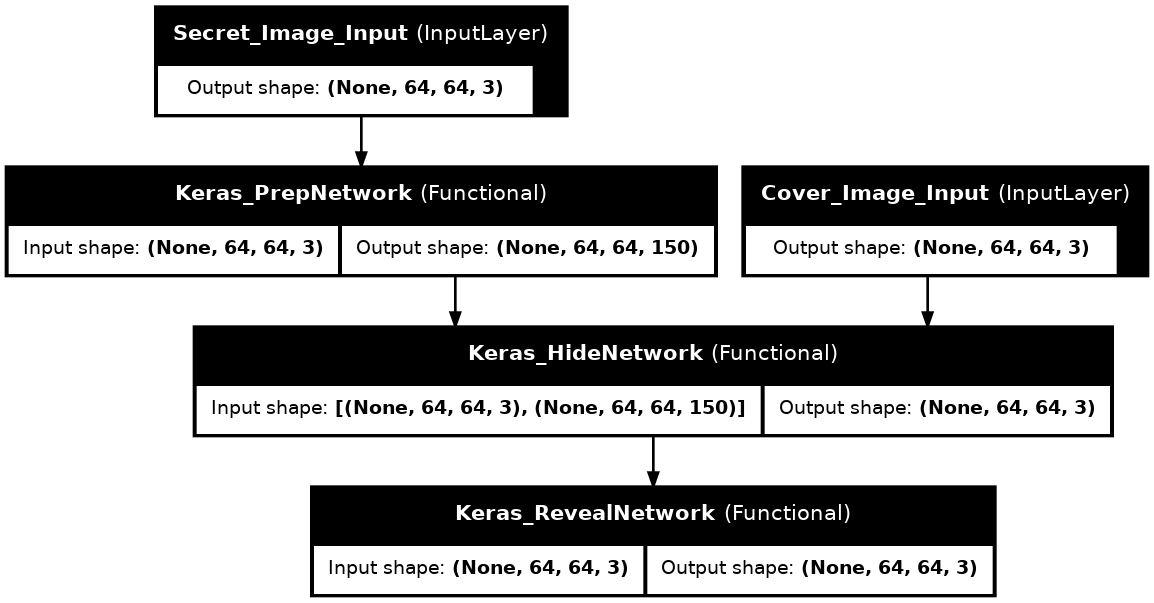

In [ ]:
import shutil
import os


# Check if the folder exists, then delete it
if CLEAR_BEFORE_TRAIN and os.path.exists(checkpoint_dir) and os.path.exists(models_dir):
    try:
        shutil.rmtree(checkpoint_dir)
        shutil.rmtree(models_dir)
        shutil.rmtree(data_dir)
        print(
            f"🗑️  Existing checkpoints in '{checkpoint_dir}' and models in '{models_dir}' have been cleared.")
    except Exception as e:
        print(f"⚠️  Error clearing checkpoints: {e}")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

# Create the integrated model
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=EPOCHS * STEPS,  # Total number of training steps
    alpha=0.01
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    global_clipnorm=1.0
)


# Wrap it for your StegoSystem
tools = {
    'codec': codec,
    # Ensure keys match your 'methods' list
    **stego_map
}

model = StegoSystem(
    prep_net=prep_network,
    hide_net=hide_network,
    reveal_net=reveal_network,
    stego_tools=tools,
    steps_per_epoch=STEPS,
    max_safe_chars=max_safe_word_len,
    alpha=ALPHA,
    beta=BETA,
    noise_start_epoch=START_NOISE_EP,
    noise_peak_epoch=PEAK_NOISE_EP
)

model.build([(None, 64, 64, 3), (None, 64, 64, 3)])
model.compile(optimizer=optimizer, jit_compile=False)


def plot_steganography_graph():
    secret_in = tf.keras.Input(shape=(64, 64, 3), name="Secret_Image_Input")
    cover_in = tf.keras.Input(shape=(64, 64, 3), name="Cover_Image_Input")

    prep_out = prep_network(secret_in)
    stego_out = hide_network([cover_in, prep_out])
    reveal_out = reveal_network(stego_out)

    viz_model = tf.keras.Model(
        inputs=[cover_in, secret_in],
        outputs=[stego_out, reveal_out],
        name="Steganography_Architecture"
    )

    return tf.keras.utils.plot_model(
        viz_model,
        to_file='steganography_full_flow.png',
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=False,
        dpi=96,
        layer_range=None,
        show_layer_activations=False
    )


# Execute the plot
model.summary()
plot_steganography_graph()


In [ ]:
class SaveEveryTen(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_dir, max_to_keep=3):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.max_to_keep = max_to_keep
        # Track saved epochs to know what to delete
        self.saved_epochs = []

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        if current_epoch % 10 == 0:
            print(f"\n✅ Milestone: Epoch {current_epoch} completed.")

            if len(self.saved_epochs) >= self.max_to_keep:
                oldest_epoch = self.saved_epochs.pop(0)
                self._delete_checkpoint(oldest_epoch)

            self._save_checkpoint(current_epoch)
            self.saved_epochs.append(current_epoch)

    def _save_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            net = getattr(self.model, f"{net_name}_net")
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            net.save(path)

    def _delete_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            if os.path.exists(path):
                os.remove(path)


# Callback to save every 10 epochs
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/stego_best_val.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)


callbacks = [checkpoint_callback,
             SaveEveryTen(checkpoint_dir=checkpoint_dir, max_to_keep=3),

             ]

# Train using Keras Fit
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=callbacks,
    verbose=1
)


model.prep_net.save(prep_model_path)
model.hide_net.save(hide_model_path)
model.reveal_net.save(reveal_model_path)
print("Training completed.Final model states saved.")

results = model.evaluate(test_dataset)
print(
    f"Validation Results - Total Loss: {results[0]:.4f}, Cover Loss: {results[1]:.4f}, Secret Loss: {results[2]:.4f}")


Epoch 1/100


I0000 00:00:1775093778.671924   98386 cuda_dnn.cc:461] Loaded cuDNN version 92000


  9/118 ━━━━━━━━━━━━━━━━━━━━ 39s 361ms/step - cover_loss: 0.0786 - cover_psnr: 11.4546 - loss: 13.8798 - lr: 1.0000e-03 - noise_prob: 0.0000e+00 - payload_len: 0.0000e+00 - psnr_dct: 0.0000e+00 - psnr_dwt: 0.0000e+00 - psnr_lsb: 0.0000e+00 - psnr_none: 11.4546 - psnr_spread_spectrum: 0.0000e+00 - psnr_statistical: 0.0000e+00 - secret_loss: 0.6901 - secret_ssim: 0.1486 - ssim_dct: 0.0000e+00 - ssim_dwt: 0.0000e+00 - ssim_lsb: 0.0000e+00 - ssim_none: 0.1486 - ssim_spread_spectrum: 0.0000e+00 - ssim_statistical: 0.0000e+00

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import os

hist_dict = history.history if hasattr(history, 'history') else history

# Save to CSV
filename = os.path.join(data_dir, 'training_history.csv')
df = pd.DataFrame(hist_dict)
df.index.name = 'epoch'
df.to_csv(filename)

epochs = list(range(1, len(next(iter(hist_dict.values()))) + 1))

# Create 3 subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Loss Convergence (Detailed)",
        "Fidelity: Cover PSNR & Secret SSIM",
        "Schedules: LR & Noise Prob",
        "Payload vs Loss Relationship"
    ),
    horizontal_spacing=0.1,
    vertical_spacing=0.15,
    specs=[
        [{"secondary_y": False}, {"secondary_y": True}],
        [{"secondary_y": True}, {"secondary_y": False}]
    ]
)

# --- Panel 1: Losses with High Contrast & Fills ---
# Total Loss (primary)
fig.add_trace(go.Scatter(
    x=epochs, y=hist_dict['loss'],
    name="Train Total Loss",
    line=dict(color='#1f77b4', width=3),
    fill='tozeroy',
    fillcolor='rgba(31, 119, 180, 0.1)'
), row=1, col=1)

# Validation Loss
if 'val_loss' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['val_loss'],
        name="Val Total Loss",
        line=dict(color='#1f77b4', width=2, dash='dash')
    ), row=1, col=1)

# Cover loss
fig.add_trace(go.Scatter(
    x=epochs, y=hist_dict['cover_loss'],
    name="Cover MSE",
    line=dict(color='#d62728', width=2, dash='dash')
), row=1, col=1)

# Secret loss
fig.add_trace(go.Scatter(
    x=epochs, y=hist_dict['secret_loss'],
    name="Secret BCE",
    line=dict(color='#2ca02c', width=2, dash='dot')
), row=1, col=1)

# --- Panel 2: Fidelity (PSNR & SSIM) ---
# --- PSNR (Purple family) ---
if 'cover_psnr' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['cover_psnr'],
        name="Train PSNR",
        line=dict(color='#9467bd', width=4)
    ), row=1, col=2, secondary_y=False)

if 'val_cover_psnr' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['val_cover_psnr'],
        name="Val PSNR",
        line=dict(color='#9467bd', width=2, dash='dash')
    ), row=1, col=2, secondary_y=False)

# --- SSIM (Black family) ---
if 'secret_ssim' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['secret_ssim'],
        name="Train SSIM",
        line=dict(color='#111111', width=3)
    ), row=1, col=2, secondary_y=True)

if 'val_secret_ssim' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['val_secret_ssim'],
        name="Val SSIM",
        line=dict(color='#111111', width=2, dash='dot')
    ), row=1, col=2, secondary_y=True)

methods = ['lsb', 'dct', 'dwt', 'spread_spectrum', 'statistical']
method_colors = {
    'lsb': '#4C78A8',
    'dct': '#F58518',
    'dwt': '#54A24B',
    'spread_spectrum': '#E45756',
    'statistical': '#B279A2'
}

# PSNR per method
for m in methods:
    key = f'psnr_{m}'
    if key in hist_dict:
        fig.add_trace(go.Scatter(
            x=epochs,
            y=hist_dict[key],
            name=f"PSNR ({m})",
            line=dict(color=method_colors[m], width=1.5, dash='dot'),
            opacity=0.6
        ), row=1, col=2, secondary_y=False)

# SSIM per method
for m in methods:
    key = f'ssim_{m}'
    if key in hist_dict:
        fig.add_trace(go.Scatter(
            x=epochs,
            y=hist_dict[key],
            name=f"SSIM ({m})",
            line=dict(color=method_colors[m], width=1.5, dash='longdash'),
            opacity=0.6
        ), row=1, col=2, secondary_y=True)

# --- Panel 3: Schedules ---
# Learning rate (yellow)
if 'lr' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['lr'],
        name="LR",
        line=dict(color='#f2c94c', width=2)
    ), row=2, col=1, secondary_y=False)

# Noise probability (green)
if 'noise_prob' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['noise_prob'],
        name="Noise Prob",
        line=dict(color='#27ae60', width=3),
        fill='tozeroy',
        fillcolor='rgba(39, 174, 96, 0.2)'
    ), row=2, col=1, secondary_y=True)

# Payload (pink)
if 'payload_len' in hist_dict:
    fig.add_trace(go.Scatter(
        x=epochs, y=hist_dict['payload_len'],
        name="Payload Length",
        line=dict(color='#ff4da6', width=2, dash='dot')
    ), row=2, col=1, secondary_y=True)

# --- Panel 3: Payload Scatterplot ---
if 'payload_len' in hist_dict:
    fig.add_trace(go.Scatter(
        x=hist_dict['payload_len'],
        y=hist_dict['loss'],
        mode='markers',
        name="Loss vs Payload (epoch)",
        marker=dict(
            size=7,
            color=epochs,
            colorscale='Turbo',  # better than Viridis for progression
            showscale=True,
            colorbar=dict(title="Epoch")
        )
    ), row=2, col=2)

# --- Formatting ---
# Panel 1
fig.update_yaxes(title_text="Loss (MSE/BCE)", row=1, col=1)

# Panel 2
fig.update_yaxes(title_text="PSNR (dB)", range=[
                 10, 50], row=1, col=2, secondary_y=False)
fig.update_yaxes(title_text="SSIM", range=[
                 0, 1.05], row=1, col=2, secondary_y=True)

# Panel 3
fig.update_yaxes(type="log", title_text="LR (Log)",
                 row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="Noise Prob / Payload",
                 range=[0, 1.05], row=2, col=1, secondary_y=True)

# Panel 4
fig.update_xaxes(title_text="Payload Length (chars)", row=2, col=2)
fig.update_yaxes(title_text="Total Loss", row=2, col=2)

for col, row in [(1, 1), (1, 2), (2, 1)]:
    fig.add_vline(
        x=START_NOISE_EP,
        line_dash="dash",
        line_color="gray",
        annotation_text="Noise Start",
        annotation_position="top left",
        row=1, col=1
    )

fig.update_layout(
    height=550, width=1800,
    title_text="Steganography Model Audit: Multitask Convergence vs. Fidelity",
    template="plotly_white",
    hovermode="x unified",  # Shows all values in one tooltip when hovering
    legend=dict(orientation="h", yanchor="bottom",
                y=1.02, xanchor="right", x=1)
)

pdf_path = os.path.join(data_dir, "training_plot.pdf")
fig.write_image(pdf_path, format="pdf", width=1800, height=550)
fig.show()


### Final Testing / Example Output

Huffman is used for all secret text, then: LSB embedding is done with [LSB_Steganography Lib](https://github.com/RobinDavid/LSB-Steganography), did ask gemini to generate basic dwt/dst to also compare with DCt/DWT embedding on images to hopefully compare robustness to the standard NN noise present in this network


In [ ]:


def calculate_text_ber(original_text, revealed_text):
    """
    Calculates the Bit Error Rate between two strings.
    Handles length mismatches by penalizing missing or extra bits as errors.
    """
    # 1. Edge Cases: Total loss or empty strings
    if not original_text and not revealed_text:
        return 0.0
    if not original_text or not revealed_text:
        return 1.0  # 100% error if one is completely empty

    # 2. Convert text to bytes (UTF-8 encoding)
    # Using errors='replace' to safely handle corrupted characters
    orig_bytes = original_text.encode('utf-8', errors='replace')
    rev_bytes = revealed_text.encode('utf-8', errors='replace')

    # 3. Convert bytes to 1D numpy bit arrays
    orig_bits = np.unpackbits(np.frombuffer(orig_bytes, dtype=np.uint8))
    rev_bits = np.unpackbits(np.frombuffer(rev_bytes, dtype=np.uint8))

    # 4. Equalize lengths by padding the shorter array with zeros
    # This ensures that dropped bits or extra "garbage" bits are counted as errors
    max_len = max(len(orig_bits), len(rev_bits))

    orig_padded = np.pad(
        orig_bits, (0, max_len - len(orig_bits)), 'constant', constant_values=0)
    rev_padded = np.pad(rev_bits, (0, max_len - len(rev_bits)),
                        'constant', constant_values=0)

    # 5. Calculate mismatches
    mismatched_bits = np.sum(orig_padded != rev_padded)

    # 6. Calculate ratio (Bounded between 0.0 and 1.0)
    return mismatched_bits / max_len


def calculate_img_ber(original, revealed):

    # Ensure we are working with 8-bit integer representations
    # We use np.clip to ensure values stay within 0-255 before casting
    orig_uint8 = np.clip(original * 255, 0, 255).astype(np.uint8)
    rev_uint8 = np.clip(revealed * 255, 0, 255).astype(np.uint8)

    # Unpack the 8-bit integers into a bit array
    # axis=-1 expands the bits for each color channel
    orig_bits = np.unpackbits(orig_uint8)
    rev_bits = np.unpackbits(rev_uint8)

    # Calculate the ratio of flipped bits to total bits
    mismatched_bits = np.sum(orig_bits != rev_bits)
    total_bits = orig_bits.size

    return mismatched_bits / total_bits

# Calculate Text Accuracy (Fixing the shadowed 'i' variable)


def acc_txt(secret, revealed):
    if len(revealed) == 0 or len(secret) == 0:
        text_acc = 0.0
    else:
        # Compare char[i] == char[i] safely using zip
        match_count = sum(1 for s_char, r_char in zip(
            secret, revealed) if s_char == r_char)

        # Divide by the original length to get the true accuracy
        text_acc = match_count / len(secret)
    return text_acc


def find_max_supported_word(word_list, codec, fixed_byte_len, use_header=False):
    """
    Finds the longest word in the list that fits within the bit-budget.
    Returns the word and its bit length.
    """
    max_bits = fixed_byte_len * 8
    supported_words = []

    for word in word_list:
        try:
            # Test encoding with the null terminator
            test_payload = word + "\0"
            bits = prepare_payload(test_payload, codec,
                                   expected_len=fixed_byte_len)

            if len(bits) <= max_bits:
                supported_words.append((word, len(bits)))
        except Exception:
            continue  # Skip words with characters not in your codec

    if not supported_words:
        return None, 0

    # Sort by character length, then bit length
    supported_words.sort(key=lambda x: (len(x[0]), x[1]), reverse=True)

    best_word, bit_size = supported_words[0]
    print(f"✅ Max Capacity Check:")
    print(f"   - Target Bit Budget: {max_bits} bits ({fixed_byte_len} bytes)")
    print(
        f"   - Longest Supported Word: '{best_word}' ({len(best_word)} chars)")
    print(
        f"   - Bit Utilization: {bit_size}/{max_bits} ({round(bit_size/max_bits*100, 1)}%)")

    return best_word, len(best_word)


def check_audit_viability(text, codec, stego_objects, image_shape=(64, 64, 3), rs_overhead=RS_BYTES):
    """Accurately checks payload size vs EACH method's capacity (bit-consistent)."""

    print(f"\n--- AUDIT VIABILITY REPORT ---")
    print(f"Payload: '{text}' ({len(text)} chars)")
    print(f"{'Method':<20} | {'Max Capacity (bits)':<20} | {'Status'}")
    print("-" * 60)

    try:
        bit_array = prepare_payload(text, codec, expected_len=fixed_byte_len)
        payload_bits = len(bit_array)
    except Exception as e:
        print(f"❌ Payload preparation failed: {e}")
        return

    for name, obj in stego_objects.items():
        max_cap = obj.get_capacity(image_shape)  # MUST be in bits

        if payload_bits <= max_cap:
            status = "✅ OK"
        else:
            status = f"❌ OVERFLOW ({payload_bits}>{max_cap})"

        print(f"{name:<20} | {max_cap:<20} | {status}")

    print("-" * 60)


def load_weights_from_checkpoint(models_dir, prep_net, hide_net, reveal_net):

    # Verify all files exist before attempting to load
    if not all(os.path.exists(p) for p in [prep_model_path, hide_model_path, reveal_model_path]):
        raise FileNotFoundError(
            f"⛔ CRITICAL: One or more .keras files not found in {models_dir}. "
            "Ensure you have run the individual .save() commands first."
        )

    prep_net = tf.keras.models.load_model(prep_model_path)
    hide_net = tf.keras.models.load_model(hide_model_path)
    reveal_net = tf.keras.models.load_model(reveal_model_path)
    print(f"💎 Individual weights successfully loaded from {models_dir}")
    return prep_net, hide_net, reveal_net


def to_display(img_tensor):
    # Accept BOTH tensor or numpy
    if isinstance(img_tensor, tf.Tensor):
        arr = img_tensor.numpy()
    else:
        arr = img_tensor

    # Remove batch if present
    if arr.ndim == 4:
        arr = arr[0]

    return np.clip(np.round(arr * 255), 0, 255).astype(np.uint8)


def save_visual_comparison(cover, secret, stego, reveal, method_name, index, save_dir):
    """Saves a side-by-side comparison using Plotly in PDF format."""
    os.makedirs(save_dir, exist_ok=True)

    # Create subplot layout (1 row, 3 columns)
    fig = make_subplots(
        rows=1, cols=4,
        subplot_titles=(
            "1. Original Cover", f"2. Secret ({method_name})", "3. Network Output (Stego)", "4. Reveal Image")
    )

    # Add images
    fig.add_trace(go.Image(z=cover), row=1, col=1)
    fig.add_trace(go.Image(z=secret), row=1, col=2)
    fig.add_trace(go.Image(z=stego), row=1, col=3)
    fig.add_trace(go.Image(z=reveal), row=1, col=4)

    # Update layout: Remove axes, set background to white, and adjust size
    fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
    fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)

    fig.update_layout(
        width=1200,
        height=450,
        margin=dict(l=20, r=20, t=50, b=20),
        template="plotly_white"
    )

    # Save as PDF
    file_path = os.path.join(save_dir, f"sample_{index}_{method_name}.pdf")
    fig.write_image(file_path, format="pdf")


def plot_final_summary(metrics_list, save_path):
    df = pd.DataFrame(metrics_list)

    # --- 1. Data Aggregation ---
    # Calculate the average across all images for each method
    avg_df = df.groupby('method').mean().reset_index()

    # Define method order to maintain the Spatial vs Frequency logic
    spatial_methods = ['original', 'lsb', 'statistical']
    frequency_methods = ['dct', 'dwt', 'spread_spectrum']
    methods = [m for m in (spatial_methods + frequency_methods)
               if m in avg_df['method'].values]

    colors = {
        'original': '#2C3E50',       # Dark Slate
        'lsb': '#E67E22',            # Carrot Orange
        'statistical': '#F1C40F',    # Sunflower Yellow
        'dct': '#2980B9',            # Belize Blue
        'dwt': '#16A085',            # Green Sea
        'spread_spectrum': '#8E44AD'  # Wisteria Purple
    }

    # --- 2. Plot Initialization ---
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Avg Total Training/Audit Loss", "Avg PSNR: Cover vs Secret",
                        "Avg SSIM: Cover vs Secret", "Avg Reliability: Acc | Text BER | Img BER"),
        vertical_spacing=0.15, horizontal_spacing=0.1
    )

    # Labels for the X-axis
    labels = [m.replace('_', ' ').upper() for m in methods]

    # --- 3. Subplot Logic ---

    # Subplot 1: Total Loss
    fig.add_trace(go.Bar(
        x=labels,
        y=[avg_df[avg_df['method'] == m]['total_loss'].values[0]
            for m in methods],
        marker_color=[colors[m] for m in methods],
        name="Total Loss",
        showlegend=False
    ), row=1, col=1)

    # Subplot 2: PSNR (Grouped Bar: Cover vs Secret)
    psnr_c = [avg_df[avg_df['method'] == m]['psnr_c'].values[0]
              for m in methods]
    psnr_s = [avg_df[avg_df['method'] == m]['psnr_s'].values[0]
              for m in methods]

    fig.add_trace(go.Bar(x=labels, y=psnr_c, name='PSNR Cover',
                  marker_color='#34495E'), row=1, col=2)
    fig.add_trace(go.Bar(x=labels, y=psnr_s, name='PSNR Secret',
                  marker_color='#95A5A6'), row=1, col=2)

    # Subplot 3: SSIM (Grouped Bar: Cover vs Secret)
    ssim_c = [avg_df[avg_df['method'] == m]['ssim_c'].values[0]
              for m in methods]
    ssim_s = [avg_df[avg_df['method'] == m]['ssim_s'].values[0]
              for m in methods]

    fig.add_trace(go.Bar(x=labels, y=ssim_c, name='SSIM Cover',
                  marker_color='#27AE60'), row=2, col=1)
    fig.add_trace(go.Bar(x=labels, y=ssim_s, name='SSIM Secret',
                  marker_color='#2ECC71'), row=2, col=1)

    # Subplot 4: Reliability (Grouped Bar: Acc, Text BER, Img BER)
    # We filter out 'original' for reliability as it usually has no hidden data
    rel_methods = [m for m in methods if m != 'original']
    rel_labels = [m.replace('_', ' ').upper() for m in rel_methods]

    acc = [avg_df[avg_df['method'] == m]['text_acc'].values[0]
           for m in rel_methods]
    ber_t = [avg_df[avg_df['method'] == m]['ber_text'].values[0]
             for m in rel_methods]
    ber_i = [avg_df[avg_df['method'] == m]['ber_img'].values[0]
             for m in rel_methods]

    fig.add_trace(go.Bar(x=rel_labels, y=acc, name='Text Acc',
                  marker_color='#E74C3C'), row=2, col=2)
    fig.add_trace(go.Bar(x=rel_labels, y=ber_t, name='Text BER',
                  marker_color='#C0392B'), row=2, col=2)
    fig.add_trace(go.Bar(x=rel_labels, y=ber_i, name='Img BER',
                  marker_color='#F1948A'), row=2, col=2)

    # --- 4. Layout & Styling ---
    fig.update_layout(
        height=900, width=1200,
        title_text="Steganography Audit: Average Performance Comparison",
        template="plotly_white",
        barmode='group',
        legend=dict(orientation="h", yanchor="bottom",
                    y=1.02, xanchor="right", x=1)
    )

    # Axis Formatting
    fig.update_yaxes(title_text="Loss Value", row=1, col=1)
    fig.update_yaxes(title_text="dB (Higher is Better)", row=1, col=2)
    fig.update_yaxes(title_text="Index (0 to 1)", range=[0, 1.1], row=2, col=1)
    fig.update_yaxes(title_text="Rate / Accuracy",
                     range=[0, 1.1], row=2, col=2)

    fig.write_image(save_path)
    fig.show()


In [ ]:
from tqdm.auto import tqdm
import nltk
from nltk.corpus import words

# reload just to check saved model works, and so this can be run without fit if needed.
prep_network, hide_network, reveal_network = load_weights_from_checkpoint(
    models_dir, prep_network, hide_network, reveal_network
)


all_metrics = []


mse_handler = tf.keras.losses.MeanSquaredError()
methods = ['original'] + [k.lower() for k in stego_map.keys()]

num_samples = 5  # len(holdout_dataset)
print(f"Evaluating {num_samples} samples...")


sample_dataset = holdout_dataset.take(num_samples)
pbar = tqdm(enumerate(sample_dataset), total=num_samples,
            desc="Audit Progress", unit="img")

try:
    word_list = words.words()
except:
    nltk.download('words')
    # need to reimport if not downloaded
    from nltk.corpus import words
    word_list = [w.lower() for w in words.words() if w.isalpha()]

# Filter for medium-length words to ensure they fit your codec capacity
max_word, max_char_len = find_max_supported_word(
    word_list, codec, fixed_byte_len)
# subtract 2 bytes for added safety
max_char_len -= 2
safe_word_list = [w for w in word_list if len(w) <= max_char_len]

random_word = random.choice(word_list) + "\0"
check_audit_viability(random_word, codec, stego_map)


def sanitize_string(s):
    """Replaces unprintable/corrupted characters with a dot (.)"""
    if not isinstance(s, str):
        return ""
    return "".join(c if c in string.printable and c not in ['\n', '\r'] else '.' for c in s)


for i, (cover_tensor, secret_tensor) in pbar:
    # Prepare single sample
    secret_text = random.choice(word_list) + "\0"
    sc = to_scale(to_display(cover_tensor))[tf.newaxis, ...]
    original_secret_img = to_display(secret_tensor)

    for method in methods:
        # Dynamic Tool Lookup
        tool = next((v for k, v in stego_map.items()
                    if k.lower() == method), None)

        # --- 1. Embed ---
        pre_nn_text = ""
        revealed_text = ""
        embed_success = True

        if method == 'original' or tool is None:
            new_secret = original_secret_img
        else:
            try:
                new_secret = tool.embed(
                    original_secret_img, secret_text, codec
                )
                try:
                    pre_nn_text = tool.extract(new_secret, codec)
                except:
                    pre_nn_text = "[Extract Failed]"
            except Exception as e:
                embed_success = False
                new_secret = original_secret_img
                pre_nn_text = "[EMBED FAIL]"

        ss = to_scale(new_secret)[tf.newaxis, ...]

        # --- 2. Inference ---
        p_out = prep_network(ss, training=False)
        h_out = hide_network([sc, p_out], training=False)
        r_out = reveal_network(h_out, training=False)

        h_out = tf.cast(h_out, tf.float32)
        r_out = tf.cast(r_out, tf.float32)

        # --- 3. Extract & Metrics ---

        if method != 'original' and tool is not None:
            if embed_success:
                try:
                    revealed_text = tool.extract(to_display(r_out[0]), codec)
                except:
                    revealed_text = "[Extract Failed]"
            else:
                revealed_text = "[SKIPPED]"

            # Clean and truncate the strings for neat console formatting
            clean_sec = sanitize_string(secret_text.replace('\0', ''))
            clean_pre = sanitize_string(pre_nn_text.replace(
                '\0', '')) if pre_nn_text else "[EMPTY]"
            clean_rev = sanitize_string(revealed_text.replace('\0', ''))[:15]

            print(
                f"Img {i} | {method:<15} | Sec: '{clean_sec:<12}' | PreNN: '{clean_pre:<15}' | Rev: '{clean_rev:<15}'")

        text_acc = acc_txt(secret_text, revealed_text)
        ber_text = calculate_text_ber(secret_text, revealed_text)
        ber_img = calculate_img_ber(ss, r_out)

        # PSNR/SSIM
        p_c = tf.image.psnr(sc, h_out, max_val=1.0).numpy()[0]
        p_s = tf.image.psnr(ss, r_out, max_val=1.0).numpy()[0]
        s_c = tf.image.ssim(sc, h_out, max_val=1.0).numpy()[0]
        s_s = tf.image.ssim(ss, r_out, max_val=1.0).numpy()[0]

        t_loss, c_loss, s_loss = steganography_loss(sc, ss, h_out, r_out)

        # --- 4. Periodic Visual Saving ---
        # Saves every 50th image processed to avoid disk bloat
        # if (i + 1) % 10 == 0:
        save_visual_comparison(
            cover=to_display(sc[0]),
            secret=to_display(ss[0]),
            stego=to_display(h_out[0]),
            reveal=to_display(r_out[0]),
            method_name=method,
            index=i,
            save_dir=os.path.join(data_dir, "visual_results")
        )

        # --- 5. Data Accumulation ---
        all_metrics.append({
            "image_index": i,
            "method": method,
            "total_loss": float(t_loss.numpy()),
            "psnr_c": float(p_c),
            "ssim_c": float(s_c),
            "psnr_s": float(p_s),
            "ssim_s": float(s_s),
            "ber_img": float(ber_img),
            "ber_text": float(ber_text),
            "text_acc": float(text_acc)
        })

    pbar.set_postfix({"img": i, "last_acc": f"{text_acc:.2f}"})


# save all_metrics to csv here
df_metrics = pd.DataFrame(all_metrics)
final_summary_path = os.path.join(data_dir, "evaluation_metrics.csv")
df_metrics.to_csv(final_summary_path, index=False)
print(f"Metrics saved to {final_summary_path}")

# --- 2. Final Averaging ---
print("\n=== Final Average Evaluation Metrics ===")
summary = df_metrics.groupby(
    'method')[['total_loss', 'psnr_c', 'psnr_s', 'text_acc', 'ber_img', 'ber_text']].mean()
print(summary)

plot_final_summary(all_metrics, os.path.join(
    data_dir, "final_summary_plot.pdf"))
